In [1]:
%matplotlib inline
import control
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal

sns.set_style("whitegrid")

# DC Motor Position: PID Controller Design


## Key MATLAB commands used in this tutorial are:

[tf](http://www.mathworks.com/help/toolbox/control/ref/tf.html) , 

[step](http://www.mathworks.com/help/toolbox/control/ref/step.html) , 

[feedback](http://www.mathworks.com/help/toolbox/control/ref/feedback.html)


From the main problem, the open-loop transfer function of the DC Motor is

given as follows.


$$ P(s) = \frac {\Theta (s)}{V(s)} = \frac{K}{s ( (Js + b)(Ls + R) + K^2 )} \qquad [ \frac{rad}{V}  ] $$


The structure of the control system has the form shown in the figure below. 


![feedback_motorp.png](figures/feedback_motorp.png)


For the original problem setup and the derivation of the above equations,

please refer to the  

< ?example=MotorPosition&section=SystemModeling

DC Motor Position: System Modeling> page. 


For a 1-radian step reference, the design criteria are the following.


* Settling time less than 0.040 seconds

* Overshoot less than 16%

* No steady-state error, even in the presence of a step disturbance input


Now let's design a PID controller and add it into the system. First

create a new < ?aux=Extras_Mfile

m-file> and type in the following commands (refer to main

problem for the details of getting these commands). 

In [2]:

J = 3.2284E-6
b = 3.5077E-6
K = 0.0274
R = 4
L = 2.75E-6
s = control.tf('s')
P_motor = K/(s*((J*s+b)*(L*s+R)+K**2))


Recall that the transfer function for a PID controller has the following

form.


$$ C(s) = K_{p} + \frac {K_{i}} {s} + K_{d}s = \frac{K_{d}s^2 + K_{p}s + K_{i}} {s}  $$


Proportional control

Let's first try using a proportional controller with gain ranging

from 1 to 21. An *array of LTI models*, each with a different

proportional gain, can be built using a |for| loop. The

closed-loop transfer functions can be generated using the

|feedback| command. Add the following code to the end of your m-file and

run it in the MATLAB command window: 

In [3]:

Kp = 1
C = []  # List to hold controllers
for i in range(1, 4):
    C.append(control.TransferFunction([Kp], [1, 0]))  # P controller: Kp/s (integral action)
    Kp = Kp + 10

# Create closed-loop systems for each controller
sys_cl = []
for Ci in C:
    sys_cl.append(control.feedback(Ci*P_motor, 1))


Now let's see what the step responses look like. Add the following code

to the end of your m-file and again run it in the command window. You

should generate the plot shown in the figure below.

/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


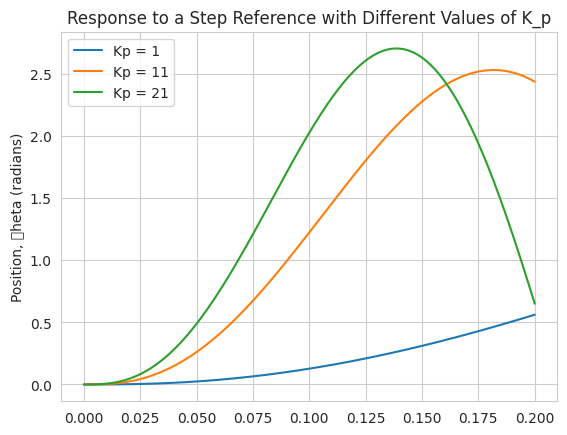

In [4]:

t = np.linspace(0, 0.2, int(round(0.2 / 0.001)) + 1)  # Evenly spaced time vector
# Get step responses for each controller
T1, yout1 = control.step_response(sys_cl[0], t)
T2, yout2 = control.step_response(sys_cl[1], t)
T3, yout3 = control.step_response(sys_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Kp = 1')
plt.plot(T2, yout2, label='Kp = 11')
plt.plot(T3, yout3, label='Kp = 21')
T = T1  # Use first time vector

plt.ylabel('Position, \theta (radians)')
plt.title('Response to a Step Reference with Different Values of K_p')
plt.legend()

plt.show()

Let's also consider the system's response to a step disturbance. In

this case, we will assume a reference of zero and look at how the

system responds to the disturbance by itself. The |feedback| command can

still be employed for generating the closed-loop transfer function

where there is still negative feedback, however, now only the

plant transfer function _P_(_s_) is in the forward path and the

controller _C_(_s_) is considered to be in the feedback path. Refer back

to the block diagram at the top of this page to see the structure of the

system. Add the following to the end of your m-file and run it in the

command window. You should generate the plot shown in the figure below.  

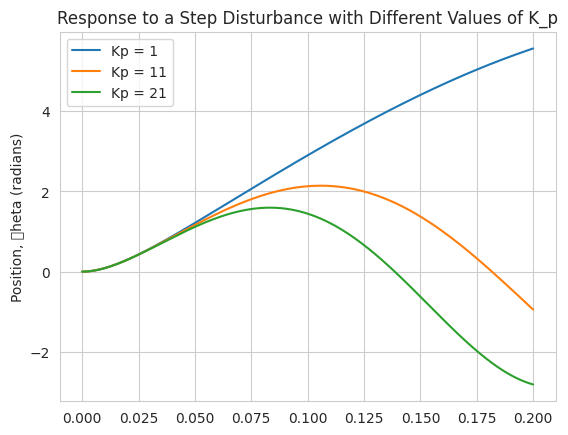

In [5]:

# Create closed-loop systems for disturbance rejection
dist_cl = []
for Ci in C:
    dist_cl.append(control.feedback(P_motor, Ci))
# Get step responses for each controller
T1, yout1 = control.step_response(dist_cl[0], t)
T2, yout2 = control.step_response(dist_cl[1], t)
T3, yout3 = control.step_response(dist_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Kp = 1')
plt.plot(T2, yout2, label='Kp = 11')
plt.plot(T3, yout3, label='Kp = 21')
T = T1
plt.ylabel('Position, \theta (radians)')
plt.title('Response to a Step Disturbance with Different Values of K_p')
plt.legend()

plt.show()

# The above plots show that the system has no steady-state error in

response to the step reference by itself, no matter the choice of

proportional gain $K_p$. This is due to the fact that the plant has an

integrator, that is, the system is type 1.  However, the system has

significant steady-state error when the disturbance is added.

Specifically, the response due to the reference and disturbance applied

simultaneously is equal to the sum of the two graphs shown above. This

follows from the property of *superposition* that holds for linear

systems. Therefore, to have zero steady-state error in the presence of a

disturbance, we need the disturbance response to decay to zero. The

larger the value of $K_p$ the smaller the steady-state error is due to the

disturbance, but it never reaches zero. Furthermore, employing

increasingly larger values of $K_p$ has the adverse effect of increasing

the overshoot and settle time as can be seen from the step reference

plot. Recall from the

< ?example=MotorPosition&section=SystemModeling

DC Motor Position: System Modeling> page that adding an integral term

will eliminate the steady-state error and a derivative term can reduce

the overshoot and settling time.


PI control

Let's first try a PI controller to get rid of the steady-state error due

to the disturbance. We will set $K_p$ = 21 and test integral gains $K_i$

ranging from 100 to 500. Change your m-file to the following and run in

the command window. You should generate a figure like the one shown

below.

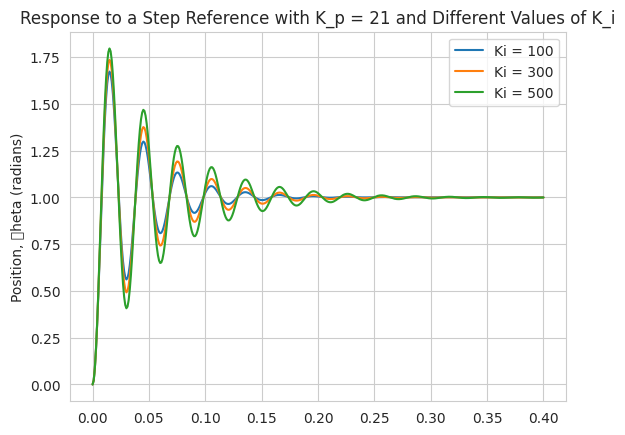

In [6]:

Kp = 21
Ki = 100
C = []  # List to hold controllers
for i in range(1, 6):
    C.append(control.TransferFunction([Kp, Ki], [1, 0]))  # PI controller: (Kp*s + Ki)/s
    Ki = Ki + 200


# Create closed-loop systems for each controller
sys_cl = []
for Ci in C:
    sys_cl.append(control.feedback(Ci*P_motor, 1))
t = np.linspace(0, 0.4, int(round(0.4 / 0.001)) + 1)  # Evenly spaced time vector
# Get step responses for each controller
T1, yout1 = control.step_response(sys_cl[0], t)
T2, yout2 = control.step_response(sys_cl[1], t)
T3, yout3 = control.step_response(sys_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Ki = 100')
plt.plot(T2, yout2, label='Ki = 300')
plt.plot(T3, yout3, label='Ki = 500')
T = T1
plt.ylabel('Position, \theta (radians)')
plt.title('Response to a Step Reference with K_p = 21 and Different Values of K_i')
plt.legend(['Ki = 100', 'Ki = 300', 'Ki = 500'])

plt.show()


Now let's see what happened to the step disturbance response. Change the

following commands in your m-file and re-run in the command window. You

should generate a plot like the one shown in the figure below.

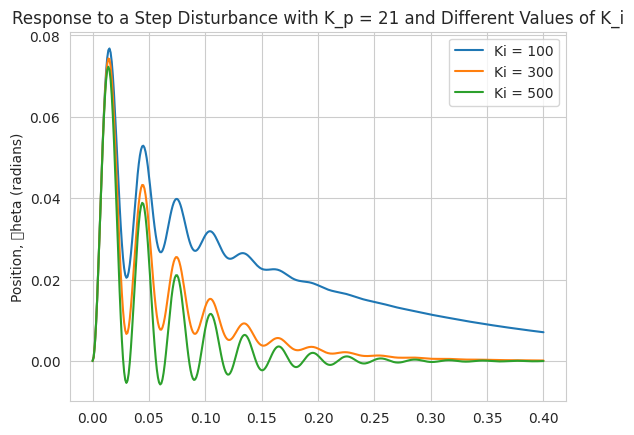

In [7]:

# Create closed-loop systems for disturbance rejection
dist_cl = []
for Ci in C:
    dist_cl.append(control.feedback(P_motor, Ci))
# Get step responses for each controller
T1, yout1 = control.step_response(dist_cl[0], t)
T2, yout2 = control.step_response(dist_cl[1], t)
T3, yout3 = control.step_response(dist_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Ki = 100')
plt.plot(T2, yout2, label='Ki = 300')
plt.plot(T3, yout3, label='Ki = 500')
T = T1
plt.ylabel('Position, \theta (radians)')
plt.title('Response to a Step Disturbance with K_p = 21 and Different Values of K_i')
plt.legend()

plt.show()

The integral control has reduced the steady-state error to zero, even

when a step disturbance is present; that was the goal for adding the

integral term. For the response to the step reference, all of the

reponses look similar with the amount of oscillation increasing slightly 

as $K_i$ is made larger. However, the response due to the disturbance

changes significantly as the integral gain $K_i$ is changed. Specifically,

the larger the value of $K_i$ employed, the faster the error decays to

zero. We will choose $K_i$ = 500 because the error due to the disturbance

decays to zero quickly, even though the response to the reference has a

longer settling time and more overshoot. We will attempt to reduce the

settling time and overshoot by adding a derivative term to the controller. 

PID control

Adding a derivative term to the controller means that we now have all

three terms of the PID controller. We will investigate derivative gains

$K_d$ ranging from 0.05 to 0.25. Go back to the m-file and make the

following changes. Running the altered m-file will generate a graph like

the one shown below.

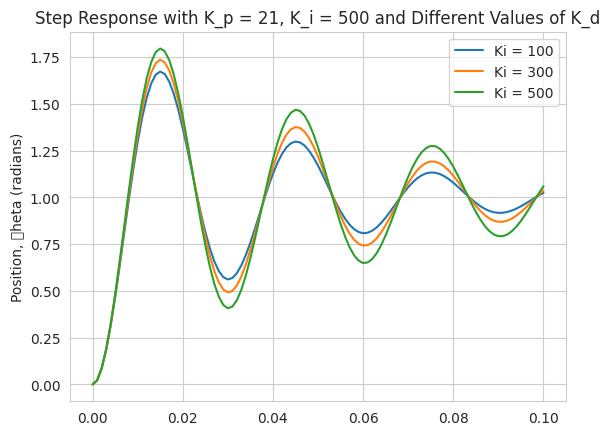

In [8]:

Kp = 21
Ki = 500
Kd = 0.05

for i in range(1, 4):
    C.append(control.TransferFunction([Kp, Ki], [1, 0]))  # PI controller: (Kp*s + Ki)/s
    Kd = Kd + 0.1


# Create closed-loop systems for each controller
sys_cl = []
for Ci in C:
    sys_cl.append(control.feedback(Ci*P_motor, 1))
t = np.linspace(0, 0.1, int(round(0.1 / 0.001)) + 1)  # Evenly spaced time vector
# Get step responses for each controller
T1, yout1 = control.step_response(sys_cl[0], t)
T2, yout2 = control.step_response(sys_cl[1], t)
T3, yout3 = control.step_response(sys_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Ki = 100')
plt.plot(T2, yout2, label='Ki = 300')
plt.plot(T3, yout3, label='Ki = 500')
T = T1
plt.ylabel('Position, \theta (radians)')
plt.title('Step Response with K_p = 21, K_i = 500 and Different Values of K_d')
plt.legend()

plt.show()


Let's see what happened to the step disturbance response, change the

following commands in your m-file and re-run at the command line. 

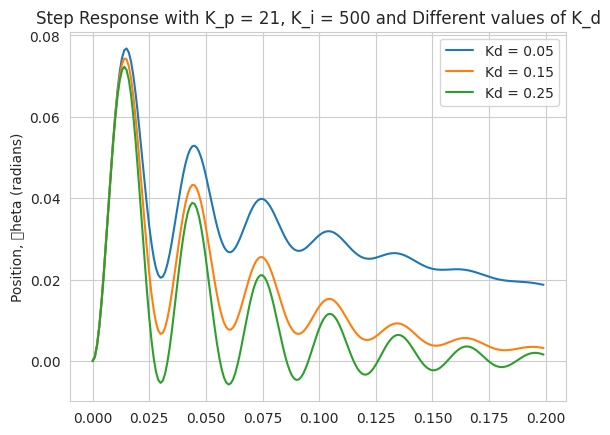

In [9]:

# Create closed-loop systems for disturbance rejection
dist_cl = []
for Ci in C:
    dist_cl.append(control.feedback(P_motor, Ci))
t = np.arange(0, 0.2, 0.001)
# Get step responses for each controller
T1, yout1 = control.step_response(dist_cl[0], t)
T2, yout2 = control.step_response(dist_cl[1], t)
T3, yout3 = control.step_response(dist_cl[2], t)
# Plot all responses
plt.plot(T1, yout1, label='Ki = 100')
plt.plot(T2, yout2, label='Ki = 300')
plt.plot(T3, yout3, label='Ki = 500')
T = T1
plt.ylabel('Position, \theta (radians)')
plt.title('Step Response with K_p = 21, K_i = 500 and Different values of K_d')
plt.legend(['Kd = 0.05', 'Kd = 0.15', 'Kd = 0.25'])

plt.show()

It looks like when $K_d$ = 0.15, we can meet our design requirements.

To determine the precise characteristics of the step response you can use

the right-click menu of the step response plot, or you can use the MATLAB

command |stepinfo| as shown below.

In [10]:

control.step_info(sys_cl[1])


{'RiseTime': 0.0,
 'SettlingTime': 0.16201219300522815,
 'SettlingMin': 0.5206741852446934,
 'SettlingMax': 1.5108427569458434,
 'Overshoot': 51.084275694584335,
 'Undershoot': 0.0,
 'Peak': 1.5108427569458434,
 'PeakTime': 0.019060258000615077,
 'SteadyStateValue': 1.0}

From the above, we see that the response to a step reference has a settling time

of roughly 34ms (< 40 ms), overshoot of 12% (< 16%), and no

steady-state error. Additionally, the step disturbance response also has

no steady-state error. So now we know that if we use a PID controller with   


$K_p$ = 21, $K_i$ = 500, and $K_d$ = 0.15,


all of our design requirements will be satisfied.